We are NOT working on this! 
This is a single audio test on one "yes" wav sound. 
It selects 10 indices from the spectogram

In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
%matplotlib inline

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Text(0.5,0,'Time (index)')

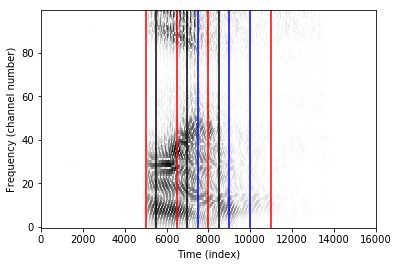

In [2]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 100
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound("0a196374_nohash_1.wav")
gfb = b2h.Gammatone(sound, cf)

X = np.abs(gfb.process().T)
#X[30:,:]*=3
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')
#'''
xcoords = np.array([ 5000, 5500, 9000, 6500, 7000,7500, 8000, 8500, 10000, 11000])
colors = ['r','k','b','r','k','b','r','k','b','r','k']
for xc,c in zip(xcoords,colors):
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)

plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')


Number of odors to train = 1
Number of odors to test = 9
Training odor 1
9 odors tested


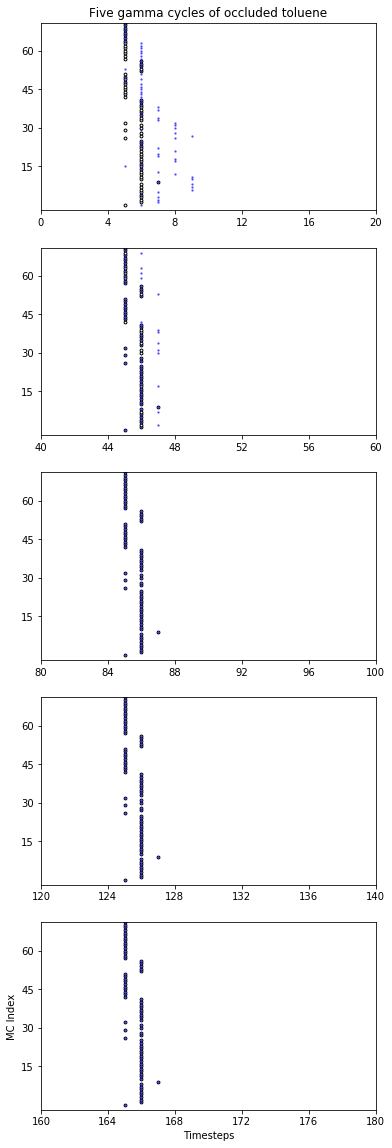

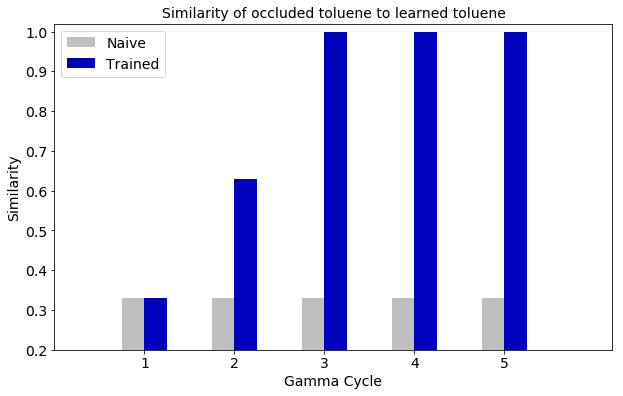

In [3]:
from lib import epl 
scale = 10
#scale = 33.6
trainingOdors = X[:,xcoords[0]].T/X.max()*scale
trainingOdors = [trainingOdors.astype(np.int64)]

testOdors = X[:,xcoords[1:]].T/X.max()*scale
testOdors = testOdors.astype(np.int64)


nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1, nGammaPerOdor = 5);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  

#Plots
plots.plotFigure3b(epl.gammaCode); 
plots.plotFigure3d(sMatrix); 



In [4]:
print(sMatrix)

[[0.33], [0.63], [1.0], [1.0], [1.0], [0.42], [0.14], [0.03], [0.0], [0.0], [0.09], [0.0], [0.0], [0.0], [0.0], [0.1], [0.01], [0.0], [0.0], [0.0], [0.22], [0.05], [0.0], [0.0], [0.0], [0.21], [0.02], [0.0], [0.0], [0.0], [0.26], [0.02], [0.0], [0.0], [0.0], [0.46], [0.52], [1.0], [1.0], [1.0], [0.39], [0.94], [1.0], [1.0], [1.0]]


In [5]:
trainingOdors

[array([15, 14, 14, 14, 14, 14, 14, 14, 14, 13, 14, 14, 14, 14, 14, 14, 14,
        14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 14, 14, 15, 14, 14, 15, 14,
        14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15,
        15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 15, 15,
        14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14],
       dtype=int64)]